# Credit Risk Modeling in Python

https://www.datacamp.com/courses/credit-risk-modeling-in-python

## Block 4 - Model Evaluation and Implementation

After developing and testing two powerful machine learning models, we use key performance metrics to compare them. Using advanced model selection techniques specifically for financial modeling, we will select one model. With that model, we will: develop a business strategy, estimate portfolio value, and minimize expected loss.

In [ ]:
# Mock Models for Comparison
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression 
from sklearn.metrics import accuracy_score
import xgboost as xgb

df = pd.read_csv("cr_loan_w2.csv")
X = df.drop("loan_status", axis=1)
y = df["loan_status"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=610)

# 1 - Logistic Regression
model_lg = LogisticRegression(solver="liblinear").fit(X_train, y_train)
pred_lg = model_lg.predict(X_test) # Classification 
pred_prob_lg = model_lg.predict_proba(X_test)[:,1] # Probability of Default
print("Accuracy Logistic Regression: " + str(accuracy_score(y_test, pred_lg)))

# 2 - Gradient Boostes Trees
model_gb = xgb.XGBClassifier().fit(X_train, y_train)
pred_gb = model_gb.predict(X_test) # Classification
pred_prob_gb = model_gb.predict_proba(X_test)[:,1] # Probability of Default
print("Accuracy XGB: " + str(accuracy_score(y_test, pred_gb))) # much better! Accuracy = (TP + TN) / (TP + TN + FP + FN)

Accuracy Logistic Regression: 0.8255261371350985
Accuracy XGB: 0.9327053632043448


### Comparing model reports

One of the easiest first steps for comparing different models' ability to predict the probability of default is to look at their metrics from the **classification_report()**.

In [2]:
from sklearn.metrics import classification_report

target_names = ["Non-Default", "Default"]

# Report Logistic Regression
print(classification_report(y_test, pred_lg, target_names=target_names))

# Report XGB
print(classification_report(y_test, pred_gb, target_names=target_names))

              precision    recall  f1-score   support

 Non-Default       0.83      0.97      0.90      9232
     Default       0.74      0.30      0.43      2552

    accuracy                           0.83     11784
   macro avg       0.78      0.64      0.66     11784
weighted avg       0.81      0.83      0.80     11784

              precision    recall  f1-score   support

 Non-Default       0.93      0.99      0.96      9232
     Default       0.95      0.73      0.82      2552

    accuracy                           0.93     11784
   macro avg       0.94      0.86      0.89     11784
weighted avg       0.93      0.93      0.93     11784



### Comparing with ROCs (receiver operating characteristic)

A graph of **true positive rate** (= recall) versus **false positive rate** for different classification thresholds in binary classification.

- True Positive Rate (TPR) = TP / (TP + FN)
- False Positive Rate (FPR) = FP / (FP + TP)

Logistic Regression AUC score: 0.7900308335325404
XGB AUC score: 0.9456229405828439


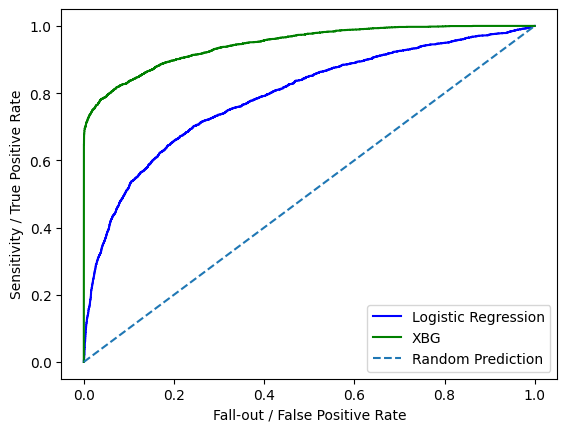

In [3]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# ROC chart variables
fallout_lr, sensitivity_lr, thresholds_lr = roc_curve(y_test, pred_prob_lg)
fallout_gbt, sensitivity_gbt, thresholds_gbt = roc_curve(y_test, pred_prob_gb)

# Plot
plt.plot(fallout_lr, sensitivity_lr, c="blue", label="Logistic Regression")
plt.plot(fallout_gbt, sensitivity_gbt, c="green", label="XBG") # XGB has larger AUC!
plt.plot([0,1], [0,1], linestyle="--", label="Random Prediction")
plt.xlabel("Fall-out / False Positive Rate")
plt.ylabel("Sensitivity / True Positive Rate")
plt.legend()

# AUC Scores
print("Logistic Regression AUC score: " + str(roc_auc_score(y_test, pred_prob_lg)))
print("XGB AUC score: " + str(roc_auc_score(y_test, pred_prob_gb)))

### Acceptance rates

Previously we set a threshold for a range of prob_default values. This was used to change the predicted loan_status of the loan.

**For all new loans, we want to deny probable defaults**.

**Acceptance rate**: percentage of new loans that are accepted to keep low the number of defaults in portfolio.

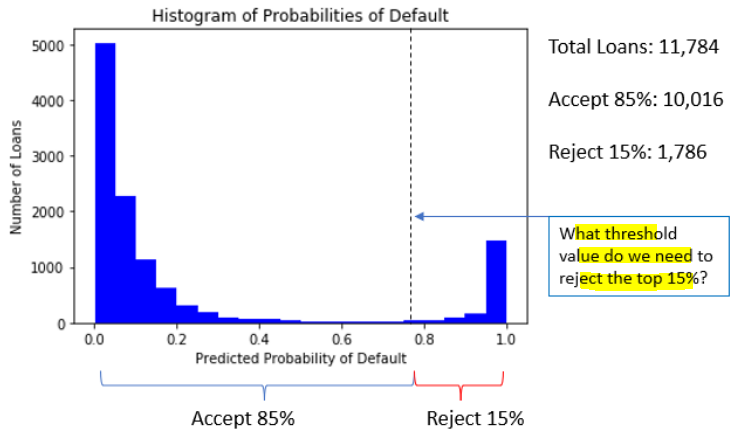

In [77]:
# Preparing data
pred = pd.DataFrame({
    "true_loan_status": y_test,
    "pred_loan_status": pred_gb,
    "prob_default": pred_prob_gb
})

pred.head()

,true_loan_status,pred_loan_status,prob_default
23390,0,0,0.022419
11283,0,0,0.231595
3022,0,0,0.193096
2345,0,0,0.005131
505,0,0,0.027421


In [78]:
# Set an acceptance rate and calculate the threshold for that rate.
import numpy as np

# Find threshold = quantile for acceptance rate of 85%
threshold = np.quantile(pred["prob_default"], 0.85)

# Apply acceptance rate threshold
pred["pred_loan_status_threshold"] = pred["prob_default"].apply(lambda x: 1 if x > threshold else 0)

print(pred["true_loan_status"].value_counts(), "\n")
print(pred["pred_loan_status"].value_counts(), "\n")
print(pred["pred_loan_status_threshold"].value_counts())

true_loan_status
0    9232
1    2552
Name: count, dtype: int64 

pred_loan_status
0    9837
1    1947
Name: count, dtype: int64 

pred_loan_status_threshold
0    10016
1     1768
Name: count, dtype: int64


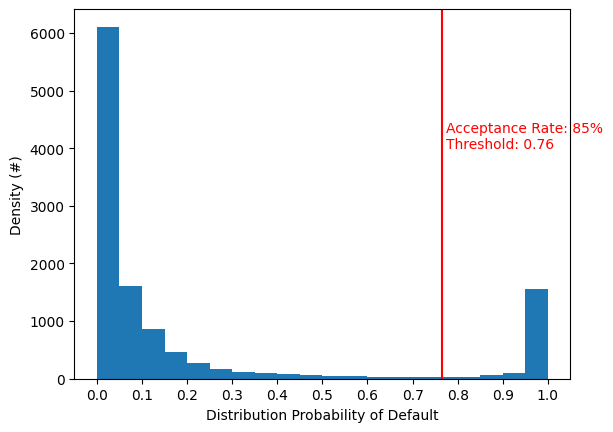

In [79]:
plt.hist(pred["prob_default"], bins=20)
plt.xticks(np.arange(0,1.1,0.1))
plt.axvline(threshold, c="r")
plt.text(x=threshold+0.01, y=4000, s=f"Acceptance Rate: 85%\nThreshold: {np.round(threshold,2)}", c="r")
plt.xlabel("Distribution Probability of Default")
plt.ylabel("Density (#)")
plt.show()

### Bad rates

**Even with a calculated threshold, some of the accepted loans will be defaults**. These are loans with prob_default values around where our model is not well calibrated.

Bad Rate = Accepted Defaults / Total Accepted  Loans

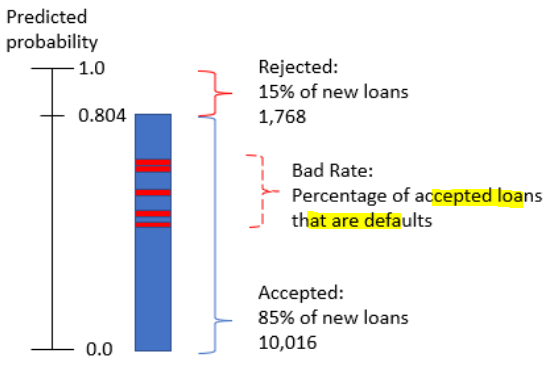

In [80]:
# Accepted Loans
accepted = pred[pred["pred_loan_status_threshold"] == 0]

# Bad Rate = Accepted Defaults / Total Accepted Loans
bad_rate = np.sum(accepted["true_loan_status"]) / len(accepted.index)
print(bad_rate) # 8% of accepted loans are default

0.07957268370607029


### Acceptance rate impact

Now, look at the loan_amnt of each loan to understand the impact on the portfolio for the acceptance rates.

In [83]:
# Avg loan amount
pred["loan_amount"] = X_test["loan_amnt"]
average_amount = np.mean(pred["loan_amount"])

# Crosstab
pd.options.display.float_format = '${:,.2f}'.format
print(pd.crosstab(pred["true_loan_status"], pred["pred_loan_status_threshold"]).apply(lambda x: x * average_amount, axis = 0))
# Our Bad Rate of 8% (= Accepted Default Loans) sum up to $7.6 mln

pred_loan_status_threshold              0              1
true_loan_status                                        
0                          $88,366,274.24    $124,608.04
1                           $7,639,431.67 $16,822,086.05
